# Głębokie Uczenie w Praktyce
## Laboratorium 11
### Mateusz Horczak


#### Ćwiczenie 1. Załaduj dane uczące (fashion_mnist) i podejrzyj ich zawartość

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

def load_real_samples():
    (train_x, train_y), (_, _) = keras.datasets.fashion_mnist.load_data()

    train_x = train_x[train_y.flatten() == 1]

    x = np.expand_dims(train_x, axis=-1)

    x = x.astype('float32')

    x = (x - 127.5) / 127.5
    return x

dataset = load_real_samples()
print("Dataset shape:", dataset.shape)

Dataset shape: (6000, 28, 28, 1)


#### Ćwiczenie 2. Budowa dyskryminatora

In [7]:
def build_discriminator():
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(128, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ], name="discriminator")
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 413,185 (1.58 MB)

 Trainable params: 413,185 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 3. Budowa generatora

In [9]:
latent_dim = 128

def build_generator(latent_size):
    model = keras.Sequential([
        keras.Input(shape=(latent_size,)),
        layers.Dense(7 * 7 * 128),
        layers.Reshape((7, 7, 128)),

        # Upsampling from 7x7 to 14x14
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),

        # Upsampling from 14x14 to 28x28
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),

        # Final layer outputting 28x28x1 image
        layers.Conv2D(1, kernel_size=7, padding="same", activation="tanh"),
    ], name="generator")
    return model

generator = build_generator(latent_dim)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 1)      │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,339,905 (5.11 MB)

 Trainable params: 1,339,905 (5.11 MB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 4. Budowa GAN- train_step

In [10]:
class GAN(keras.Model):
    def __init__(self, discriminator_model, generator_model, latent_size):
        super(GAN, self).__init__()
        self.discriminator = discriminator_model
        self.generator = generator_model
        self.latent_dim = latent_size

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        generated_images = self.generator(random_latent_vectors)
        combined_images = tf.concat([generated_images, real_images], axis=0)

        labels = tf.concat([tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0)
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        misleading_labels = tf.zeros((batch_size, 1))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}

#### Ćwiczenie 5. Trenowanie GAN

In [11]:
EPOCHS = 10
BATCH_SIZE = 64

gan = GAN(discriminator_model=discriminator, generator_model=generator, latent_size=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy()
)

history = gan.fit(
    dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - d_loss: 0.4237 - g_loss: 0.8760
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - d_loss: 0.2314 - g_loss: 1.5289
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - d_loss: 0.3400 - g_loss: 2.2990
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - d_loss: 0.4939 - g_loss: 1.8313
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - d_loss: 0.4075 - g_loss: 1.9064
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - d_loss: 0.4662 - g_loss: 1.5275
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - d_loss: 0.5749 - g_loss: 1.5404
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - d_loss: 0.5033 - g_loss: 1.5082
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - d_loss: 0.5876 - g_loss: 1.3598
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - d_loss: 0.6566 - g_loss: 1.0909


#### Ćwiczenie 6. Generowanie i wyświetlanie obrazów po wytrenowaniu GAN

X.shape: (100, 28, 28, 1)


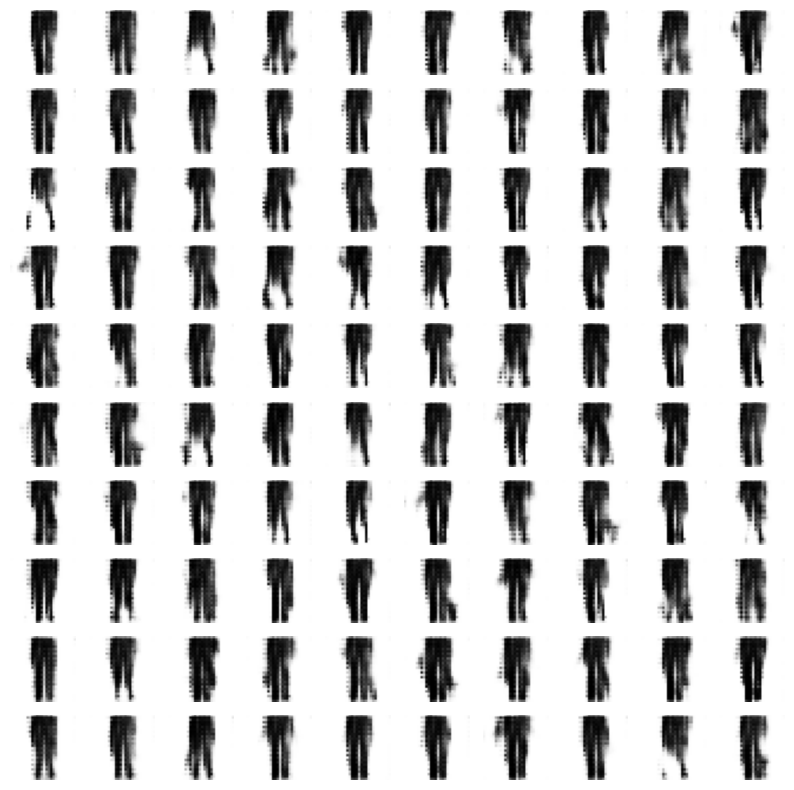

In [12]:
def generate_and_show_images(gen_model, latent_size, num_images=100):
    random_vectors = tf.random.normal(shape=(num_images, latent_size))
    generated = gen_model(random_vectors)

    generated = (generated * 127.5) + 127.5
    generated = generated.numpy()

    print(f"X.shape: {generated.shape}")

    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(10, 10, i + 1)
        plt.axis('off')
        plt.imshow(generated[i, :, :, 0], cmap='gray_r')
    plt.show()

generate_and_show_images(generator, latent_dim)

#### Ćwiczenie 7. Wizualizuj straty dyskryminatora i GAN na wykresie

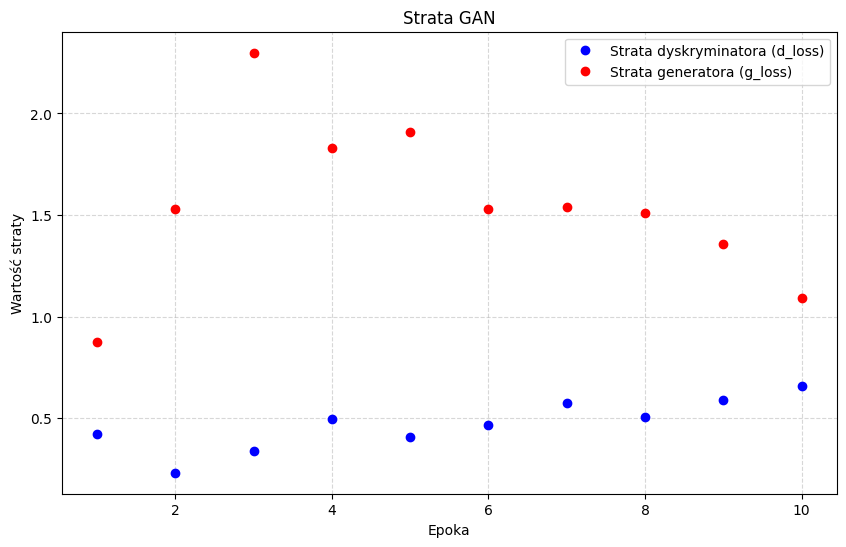

In [13]:
def plot_training_loss(training_history):
    d_loss = training_history.history['d_loss']
    g_loss = training_history.history['g_loss']
    epochs_range = range(1, len(d_loss) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(epochs_range, d_loss, 'bo', label='Strata dyskryminatora (d_loss)')
    plt.plot(epochs_range, g_loss, 'ro', label='Strata generatora (g_loss)')

    plt.title('Strata GAN')
    plt.xlabel('Epoka')
    plt.ylabel('Wartość straty')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_training_loss(history)

#### Ćwiczenie 8. Przystosuj GAN do uczenia z innym parametrami

Epoch 1/5
 1/47 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: 0.6830 - g_loss: 0.6926

E0000 00:00:1780313518.000659    7658 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/discriminator_1/leaky_re_lu_18_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/discriminator_1/conv2d_14_1/BiasAdd'.


47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - d_loss: 0.4233 - g_loss: 1.2545
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - d_loss: 0.2994 - g_loss: 3.0245
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - d_loss: 0.3543 - g_loss: 2.6212
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - d_loss: 0.1639 - g_loss: 5.5416
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - d_loss: 0.1882 - g_loss: 6.5761


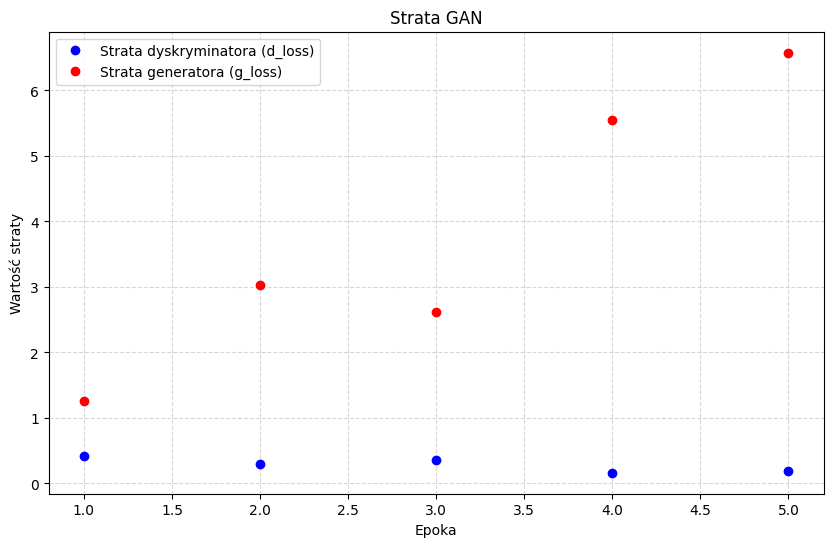

In [15]:
experimental_latent_dim = 64

exp_discriminator = build_discriminator()
exp_generator = build_generator(experimental_latent_dim)

exp_gan = GAN(
    discriminator_model=exp_discriminator,
    generator_model=exp_generator,
    latent_size=experimental_latent_dim
)

exp_gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss_fn=keras.losses.BinaryCrossentropy()
)

experimental_history = exp_gan.fit(
    dataset,
    epochs=5,
    batch_size=128
)

plot_training_loss(experimental_history)